In [6]:
from saniia.biomedical_ner import  extract_ann_dict
from pathlib import Path
from saniia.ner_split import load_split
from saniia.biomedical_ner import  extract_ann_dict,get_keywords,naive_rule_based_ner,get_predicted_dictionary
from saniia.evaluation import compare_annotation_dicts
import pprint

import matplotlib.pyplot as plt

import subprocess

# Data loading and Split

In [2]:
#Split data into train and test sets, load paths in JSON files
BASE_DIR = Path.cwd().parent
result = subprocess.run(["python", "saniia/ner_split.py"], capture_output=True, text=True,cwd=BASE_DIR)
print(result.stdout)

Saved train and test file splits.



In [3]:
# Load the pre-saved train/test split from JSON files.
train_files, test_files = load_split()
print(f"Loaded {len(train_files)} training files and {len(test_files)} test files.")

Loaded 160 training files and 40 test files.


# Symptom & Diseases keywords Extraction

In [4]:
# Obtain Keywords
symptom_keywords,disease_keywords=get_keywords(train_files)

# Evaluation

Average Metrics per Category:
{ 'Age': { 'f1': 0.7504761904761905,
           'jaccard': 0.6945833333333333,
           'precision': 0.7070833333333333,
           'recall': 0.8875},
  'Disease_disorder': { 'f1': 0.2833379666354494,
                        'jaccard': 0.18279307777276044,
                        'precision': 0.25758824508824507,
                        'recall': 0.35981601731601726},
  'Sex': {'f1': 0.85, 'jaccard': 0.85, 'precision': 0.85, 'recall': 0.85},
  'Sign_symptom': { 'f1': 0.4384971906625177,
                    'jaccard': 0.2934909531893837,
                    'precision': 0.4015516713366695,
                    'recall': 0.5219743468176131}}


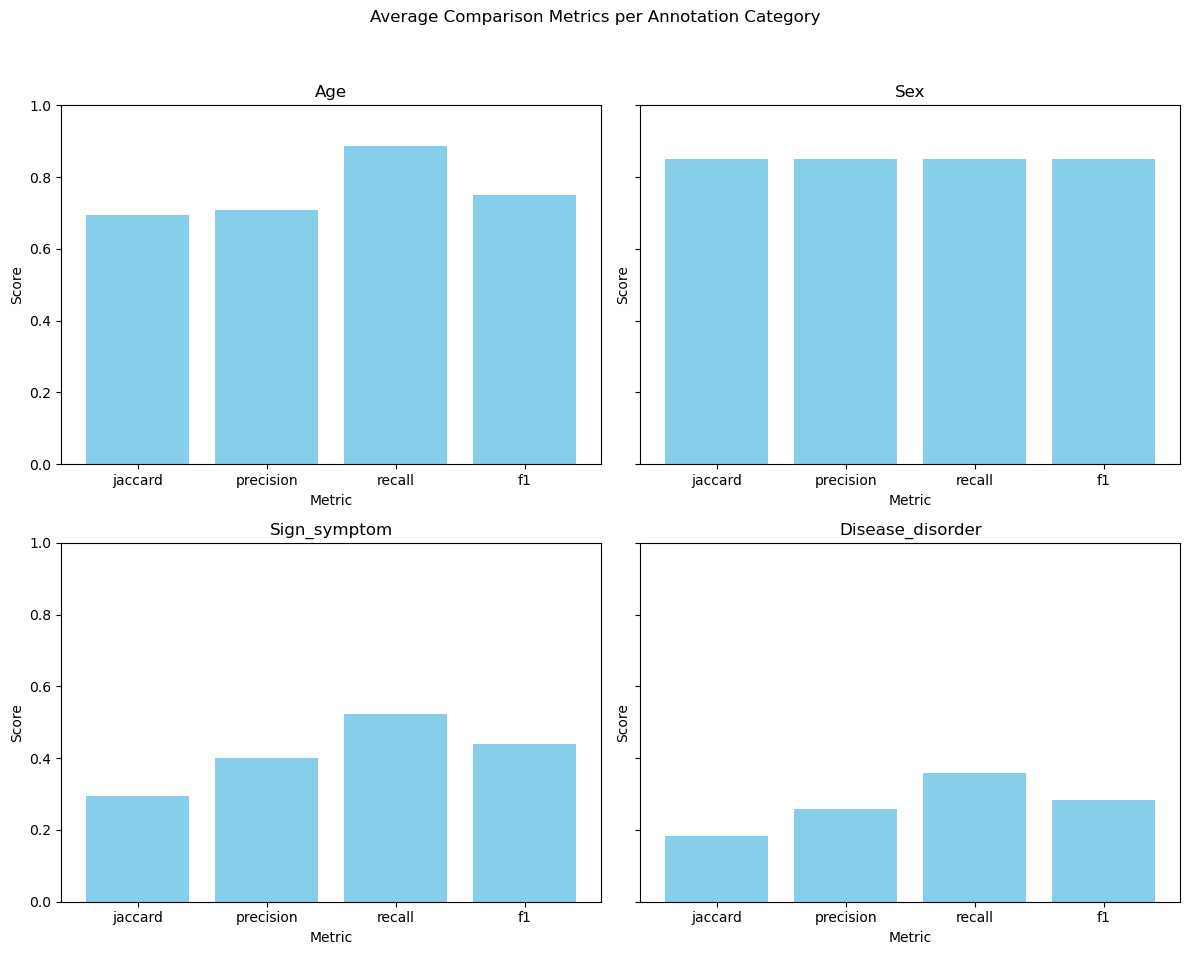

In [7]:
def evaluate_test_files(test_files, symptom_keywords, disease_keywords):
    """
    Evaluates each test file by comparing the reference annotations and the predicted annotations.
    Aggregates and returns the average comparison metrics for each annotation category.
    """
    # Dictionary to accumulate metrics for each category.
    aggregated_metrics = {}  # e.g., {'Sign_symptom': {'jaccard': [...], 'precision': [...], ...}, ...}
    
    for file_path in test_files:
        # Ensure file_path is a Path object.
        file_path = Path(file_path)
        
        # Extract the reference and predicted dictionaries.
        ref_dict = extract_ann_dict(file_path)
        cand_dict = get_predicted_dictionary(file_path, symptom_keywords, disease_keywords)
        
        # Compare the dictionaries and get metrics.
        comp_metrics = compare_annotation_dicts(ref_dict, cand_dict)
        
        # For each category in the computed metrics, accumulate the metrics.
        for key, metrics in comp_metrics.items():
            if key not in aggregated_metrics:
                aggregated_metrics[key] = {'jaccard': [], 'precision': [], 'recall': [], 'f1': []}
            aggregated_metrics[key]['jaccard'].append(metrics['jaccard'])
            aggregated_metrics[key]['precision'].append(metrics['precision'])
            aggregated_metrics[key]['recall'].append(metrics['recall'])
            aggregated_metrics[key]['f1'].append(metrics['f1'])
    
    # Compute the average metrics for each category.
    avg_metrics = {}
    for key, m in aggregated_metrics.items():
        avg_metrics[key] = {
            'jaccard': sum(m['jaccard']) / len(m['jaccard']) if m['jaccard'] else 0,
            'precision': sum(m['precision']) / len(m['precision']) if m['precision'] else 0,
            'recall': sum(m['recall']) / len(m['recall']) if m['recall'] else 0,
            'f1': sum(m['f1']) / len(m['f1']) if m['f1'] else 0,
        }
    return avg_metrics

# -------------------------
# Evaluate the test set.
# -------------------------
avg_metrics = evaluate_test_files(test_files, symptom_keywords, disease_keywords)

# Pretty-print the aggregated average metrics.
pp = pprint.PrettyPrinter(indent=2)
print("Average Metrics per Category:")
pp.pprint(avg_metrics)

# -------------------------
# Plotting the results.
# -------------------------
categories = list(avg_metrics.keys())
metric_names = ['jaccard', 'precision', 'recall', 'f1']


# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()  # Flatten to easily iterate over them

# Plot each category on one subplot
for ax, cat in zip(axes, categories):
    values = [avg_metrics[cat][metric] for metric in metric_names]
    ax.bar(metric_names, values, color='skyblue')
    ax.set_title(cat)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')

# Hide any unused subplots if there are fewer than 4 categories.
for ax in axes[len(categories):]:
    ax.axis('off')

plt.suptitle("Average Comparison Metrics per Annotation Category")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()